# DiMLex-Eng: resource inspection and lexical coverage diagnostic

**Role.** Document the released DiMLex-Eng resource, inspect its sense
ambiguity and discontinuous forms, and produce the lexical occurrence /
coverage diagnostic that the native-discopy comparison consumes. It also
reports current-corpus word and sentence-length statistics.

**Not a discourse-results notebook.** The substantive RQ2 discourse results
come from the native-discopy pipeline and live in
`7_final_discourse_analysis.ipynb`. The old model-level DiMLex result tables,
category co-occurrence matrices, marker/category plots and the
conditioned-comparison extension have been removed: they were superseded by
that analysis, and keeping a second implementation of model-level discourse
statistics invited the two to drift.

**Frozen matching.** The matcher lives in
`src/justification_analysis/dimlex/dimlex_lexicon.py` and is shared with the
discopy comparison, so notebook 2 does not require this notebook to have been
run. `MAX_COMPONENT_GAP_TOKENS = 15` was chosen during pipeline development
against the BASE corpus and is a fixed methodological choice: it is applied
identically to base and fine-tuned outputs and is never recalibrated per
stage. The sentence-length statistics below are descriptive only.

**Stage.** Inputs and outputs follow the shared `AnalysisConfig`; switching to
fine-tuned outputs is a one-line change in the setup cell.

In [1]:
# ============================================================
# 1. Parse DiMLex-Eng and build provisional categories
# ============================================================
#
# The resource parsing and the matcher are imported from the shared module, so
# this notebook and the discopy comparison use ONE implementation. Nothing
# about the matching behaviour is defined here.

import sys
from pathlib import Path


def find_repo_root(start=None, repo_name="masters_thesis_sdg"):
    current = (start or Path.cwd()).resolve()
    while current.name != repo_name:
        if current.parent == current:
            raise FileNotFoundError(f"repo root {repo_name!r} not found")
        current = current.parent
    return current


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import re
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.justification_analysis.dimlex import dimlex_lexicon as dl
from src.justification_analysis.pipeline import config as pipeline_config
from src.justification_analysis.pipeline import corpus as corpus_module
from src.justification_analysis.pipeline import manifest as manifest_module

# --- the one thing to change for a fine-tuned rerun ---------------------
CONFIG = pipeline_config.default_config(stage="base", repo_root=REPO_ROOT)

# Names re-exported from the shared module so the cells below read unchanged.
extract_component_variants = dl.extract_component_variants
format_components = dl.format_components
PAPER_REPORTED_DIMLEX_ENTRIES = dl.PAPER_REPORTED_DIMLEX_ENTRIES
RELEASED_DIMLEX_ENTRY_COUNT = dl.RELEASED_DIMLEX_ENTRY_COUNT
VALID_TOP_LEVEL_CATEGORIES = dl.VALID_TOP_LEVEL_CATEGORIES

DIMLEX_FOLDER = dl.DIMLEX_DIR
DIMLEX_XML_PATH = dl.DIMLEX_XML_PATH
if not DIMLEX_XML_PATH.exists():
    raise FileNotFoundError(f"DiMLex XML not found: {DIMLEX_XML_PATH}")

print("stage      :", CONFIG.stage)
print("DiMLex XML :", DIMLEX_XML_PATH.relative_to(REPO_ROOT))


tree = ET.parse(DIMLEX_XML_PATH)
root = tree.getroot()

entry_elements = root.findall("entry")

sense_rows = []
inventory_rows = []

# marker -> list of ordered component tuples, for the discontinuous matcher.
DISCONTINUOUS_COMPONENTS = {}

for entry in entry_elements:
    marker = entry.get("word", "").strip().lower()

    orthographies = entry.findall("./orths/orth")

    component_variants = extract_component_variants(entry)
    is_discontinuous = bool(component_variants)

    # What DiMLex itself claims about the entry, used only as a cross-check on
    # the parse above: an entry advertised as discontinuous whose components
    # cannot be recovered must be reported, not silently treated as contiguous.
    declared_discontinuous = (
        any(
            orthography.get("type") == "discont"
            for orthography in orthographies
        )
        or "/" in marker
    )

    entry_senses = [
        relation.get("sense")
        for relation in entry.findall(".//pdtb2_relation")
    ]
    entry_senses = [
        sense
        for sense in entry_senses
        if sense and sense.strip()
    ]

    has_relation_information = bool(entry_senses)

    unusable_top_levels = sorted(
        {
            sense.split(".")[0].strip().title()
            for sense in entry_senses
        }
        - VALID_TOP_LEVEL_CATEGORIES
    )

    exclusion_reasons = []

    if not marker:
        exclusion_reasons.append(
            "entry has no 'word' attribute"
        )

    if not has_relation_information:
        exclusion_reasons.append(
            "no pdtb2_relation carries a sense"
        )

    if declared_discontinuous and not is_discontinuous:
        exclusion_reasons.append(
            "declared discontinuous but no ordered components "
            "could be parsed"
        )

    if unusable_top_levels:
        exclusion_reasons.append(
            "sense outside the four PDTB top levels: "
            + ", ".join(unusable_top_levels)
        )

    inventory_rows.append(
        {
            "entry_id": entry.get("id"),
            "marker": marker or entry.get("word", ""),
            "structure": (
                "discontinuous"
                if is_discontinuous
                else "contiguous"
            ),
            "n_components": (
                len(component_variants[0])
                if component_variants
                else 1
            ),
            "components": format_components(component_variants),
            "n_orthographic_variants": len(orthographies),
            "n_relation_senses": len(entry_senses),
            "has_relation_information": has_relation_information,
            "declared_discontinuous": declared_discontinuous,
            "usable": not exclusion_reasons,
            "exclusion_reason": " ; ".join(exclusion_reasons),
        }
    )

    if exclusion_reasons:
        continue

    if is_discontinuous:
        DISCONTINUOUS_COMPONENTS[marker] = component_variants

    for relation in entry.findall(".//pdtb2_relation"):
        full_sense = relation.get("sense")

        if not full_sense:
            continue

        # Keep only the highest-level DiMLex category.
        top_level = full_sense.split(".")[0].strip().title()

        frequency = pd.to_numeric(
            relation.get("pdtb_freq"),
            errors="coerce",
        )

        sense_rows.append(
            {
                "marker": marker,
                "top_level": top_level,
                "full_sense": full_sense,
                "frequency": frequency,
                "is_discontinuous": is_discontinuous,
            }
        )


dimlex_senses_df = pd.DataFrame(sense_rows)

dimlex_entry_inventory_df = pd.DataFrame(inventory_rows)


# ============================================================
# 1.1 Source reconciliation: every entry accounted for
# ============================================================

n_source_entries = len(dimlex_entry_inventory_df)

n_with_relation = int(
    dimlex_entry_inventory_df["has_relation_information"].sum()
)
n_without_relation = n_source_entries - n_with_relation

n_usable_entries = int(dimlex_entry_inventory_df["usable"].sum())
n_unusable_entries = n_source_entries - n_usable_entries

usable_inventory_df = dimlex_entry_inventory_df.loc[
    dimlex_entry_inventory_df["usable"]
]

n_contiguous_entries = int(
    usable_inventory_df["structure"].eq("contiguous").sum()
)
n_discontinuous_entries = int(
    usable_inventory_df["structure"].eq("discontinuous").sum()
)

print("\n" + "=" * 100)
print("DIMLEX-ENG SOURCE RECONCILIATION")
print("=" * 100)

print(f"XML file: {DIMLEX_XML_PATH}")
print(
    "Entries quoted in the DiMLex-Eng paper:      "
    f"{PAPER_REPORTED_DIMLEX_ENTRIES}"
)
print(
    "Entries shipped by the public DiMLex release: "
    f"{RELEASED_DIMLEX_ENTRY_COUNT}"
)
print(
    "<entry> elements found in this XML:          "
    f"{n_source_entries}"
)

entry_ids = dimlex_entry_inventory_df["entry_id"].astype(int)

missing_ids = sorted(
    set(range(entry_ids.min(), entry_ids.max() + 1)) - set(entry_ids)
)

if n_source_entries != RELEASED_DIMLEX_ENTRY_COUNT:
    raise AssertionError(
        f"This XML holds {n_source_entries} entries, but the DiMLex-Eng "
        f"release ships {RELEASED_DIMLEX_ENTRY_COUNT}. The file has been "
        "truncated, swapped or updated; check it before trusting any count "
        "below."
    )

print(
    f"\nThe local file matches the public release exactly: "
    f"{n_source_entries} entries, ids {entry_ids.min()}-{entry_ids.max()}, "
    f"no gaps ({missing_ids or 'none missing'}), no duplicate marker strings."
)

if RELEASED_DIMLEX_ENTRY_COUNT != PAPER_REPORTED_DIMLEX_ENTRIES:
    print(
        "\nNOTE: the DiMLex-Eng paper quotes "
        f"{PAPER_REPORTED_DIMLEX_ENTRIES} entries, "
        f"{PAPER_REPORTED_DIMLEX_ENTRIES - RELEASED_DIMLEX_ENTRY_COUNT} more "
        "than the released lexicon contains. That gap is between the "
        "publication and the distributed XML - it was verified against the "
        "upstream repository, and is not a download, parsing or preprocessing "
        "loss here. The released lexicon is what can be matched against, so "
        f"every figure in this notebook is computed over {n_source_entries} "
        "entries and should be reported as such."
    )

print(
    f"\n  {n_source_entries} source entries"
    f"\n    with usable PDTB relation information:    {n_with_relation}"
    f"\n    without usable PDTB relation information: {n_without_relation}"
    f"\n    usable overall (word + sense + structure): {n_usable_entries}"
    f"\n    excluded, each for an explicit reason:     {n_unusable_entries}"
    f"\n\n  of the {n_usable_entries} usable entries:"
    f"\n    contiguous:    {n_contiguous_entries}"
    f"\n    discontinuous: {n_discontinuous_entries}"
)

assert n_source_entries == n_usable_entries + n_unusable_entries
assert n_usable_entries == n_contiguous_entries + n_discontinuous_entries
assert (
    dimlex_entry_inventory_df["marker"].nunique() == n_source_entries
), "duplicate marker strings in DiMLex: the marker key would collide"

print("\nExcluded entries and their reasons:")
if n_unusable_entries:
    display(
        dimlex_entry_inventory_df.loc[
            ~dimlex_entry_inventory_df["usable"],
            ["entry_id", "marker", "structure", "exclusion_reason"],
        ].reset_index(drop=True)
    )
else:
    print("  (none: every entry in the file is usable)")

print("\nDiscontinuous entries parsed out of the XML:")
display(
    usable_inventory_df.loc[
        usable_inventory_df["structure"].eq("discontinuous"),
        [
            "entry_id",
            "marker",
            "components",
            "n_components",
            "declared_discontinuous",
            "n_relation_senses",
        ],
    ].reset_index(drop=True)
)


# -----------------------------
# Sum evidence by marker and broad category
# -----------------------------

marker_category_scores_df = (
    dimlex_senses_df
    .groupby(
        ["marker", "top_level", "is_discontinuous"],
        as_index=False,
    )
    .agg(
        summed_frequency=(
            "frequency",
            lambda values: values.sum(min_count=1),
        ),
        n_sense_entries=("full_sense", "size"),
    )
)


# -----------------------------
# Assign one provisional category to every marker
# -----------------------------

assignment_rows = []

for marker, marker_group in marker_category_scores_df.groupby(
    "marker",
    sort=True,
):
    marker_group = marker_group.copy()

    has_frequency = (
        marker_group["summed_frequency"].notna().any()
        and marker_group["summed_frequency"].fillna(0).sum() > 0
    )

    if has_frequency:
        marker_group["assignment_score"] = (
            marker_group["summed_frequency"].fillna(0)
        )
        assignment_method = "highest summed DiMLex frequency"
    else:
        marker_group["assignment_score"] = (
            marker_group["n_sense_entries"].astype(float)
        )
        assignment_method = "largest number of DiMLex sense entries"

    marker_group = (
        marker_group
        .sort_values(
            ["assignment_score", "top_level"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )

    highest_score = marker_group.loc[0, "assignment_score"]

    winning_categories = marker_group.loc[
        marker_group["assignment_score"].eq(highest_score),
        "top_level",
    ].tolist()

    # Exact ties are resolved alphabetically for reproducibility.
    # They remain explicitly flagged for inspection.
    provisional_category = winning_categories[0]
    exact_tie = len(winning_categories) > 1

    total_score = marker_group["assignment_score"].sum()

    dominance_share = (
        highest_score / total_score
        if total_score > 0
        else np.nan
    )

    category_scores = " | ".join(
        f"{row.top_level}: {row.assignment_score:g}"
        for row in marker_group.itertuples()
    )

    possible_senses = sorted(
        dimlex_senses_df.loc[
            dimlex_senses_df["marker"].eq(marker),
            "full_sense",
        ].unique()
    )

    component_variants = DISCONTINUOUS_COMPONENTS.get(marker, [])

    assignment_rows.append(
        {
            "marker": marker,
            "provisional_category": provisional_category,
            "possible_categories": " | ".join(
                marker_group["top_level"].tolist()
            ),
            "n_possible_categories": marker_group["top_level"].nunique(),
            "category_scores": category_scores,
            "dominance_share": dominance_share,
            "exact_tie": exact_tie,
            "assignment_method": assignment_method,
            "possible_senses": " | ".join(possible_senses),
            "is_discontinuous": bool(
                marker_group["is_discontinuous"].max()
            ),
            "components": format_components(component_variants),
            "n_components": (
                len(component_variants[0])
                if component_variants
                else 1
            ),
            "component_variants_json": json.dumps(
                [list(variant) for variant in component_variants]
            ),
        }
    )


marker_assignment_df = (
    pd.DataFrame(assignment_rows)
    .sort_values(["provisional_category", "marker"])
    .reset_index(drop=True)
)



print("\n" + "=" * 100)
print("DIMLEX ASSIGNMENT SUMMARY")
print("=" * 100)

print("Unique DiMLex markers:", marker_assignment_df["marker"].nunique())
print(
    "  contiguous:   ",
    int((~marker_assignment_df["is_discontinuous"]).sum()),
)
print(
    "  discontinuous:",
    int(marker_assignment_df["is_discontinuous"].sum()),
)
print(
    "Markers with multiple broad categories:",
    marker_assignment_df["n_possible_categories"].gt(1).sum(),
)
print("Exact ties:", marker_assignment_df["exact_tie"].sum())

print("\nProvisional category counts:")
display(
    marker_assignment_df[
        "provisional_category"
    ]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n_markers")
)

print("\nAll markers with multiple possible broad categories:")
display(
    marker_assignment_df.loc[
        marker_assignment_df["n_possible_categories"].gt(1),
        [
            "marker",
            "provisional_category",
            "possible_categories",
            "category_scores",
            "dominance_share",
            "exact_tie",
            "is_discontinuous",
        ],
    ]
    .sort_values(
        ["exact_tie", "dominance_share", "marker"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)


stage      : base
DiMLex XML : src\justification_analysis\dimlex\en_dimlex.xml

DIMLEX-ENG SOURCE RECONCILIATION
XML file: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\src\justification_analysis\dimlex\en_dimlex.xml
Entries quoted in the DiMLex-Eng paper:      149
Entries shipped by the public DiMLex release: 142
<entry> elements found in this XML:          142

The local file matches the public release exactly: 142 entries, ids 1-142, no gaps (none missing), no duplicate marker strings.

NOTE: the DiMLex-Eng paper quotes 149 entries, 7 more than the released lexicon contains. That gap is between the publication and the distributed XML - it was verified against the upstream repository, and is not a download, parsing or preprocessing loss here. The released lexicon is what can be matched against, so every figure in this notebook is computed over 142 entries and should be reported as such.

  142 source entries
    with usable PDTB relation information:    142
    without usable PD

,entry_id,marker,components,n_components,declared_discontinuous,n_relation_senses
0,42,either or,either ... or,2,True,3
1,69,if then,if ... then,2,True,5
2,79,neither nor,neither ... nor,2,True,3
3,100,on the one hand on the other hand,on the one hand ... on the other hand,2,True,1
4,105,when/then,when ... then,2,True,1
5,140,not only/but,not only ... but,2,True,1



DIMLEX ASSIGNMENT SUMMARY
Unique DiMLex markers: 142
  contiguous:    136
  discontinuous: 6
Markers with multiple broad categories: 49
Exact ties: 6

Provisional category counts:


,category,n_markers
0,Expansion,52
1,Contingency,32
2,Temporal,30
3,Comparison,28



All markers with multiple possible broad categories:


,marker,provisional_category,possible_categories,category_scores,dominance_share,exact_tie,is_discontinuous
0,at the same time,Comparison,Comparison | Expansion | Temporal,Comparison: 1 | Expansion: 1 | Temporal: 1,0.333333,True,False
1,after all,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,0.500000,True,False
2,by the way,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,0.500000,True,False
3,instead of,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,0.500000,True,False
4,lest,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,0.500000,True,False
5,much as,Comparison,Comparison | Expansion,Comparison: 3 | Expansion: 3,0.500000,True,False
6,meanwhile,Temporal,Temporal | Expansion | Comparison,Temporal: 94 | Expansion: 70 | Comparison: 29,0.487047,False,False
7,since,Contingency,Contingency | Temporal,Contingency: 96 | Temporal: 88,0.521739,False,False
8,in the end,Expansion,Expansion | Comparison | Contingency | Temporal,Expansion: 5 | Comparison: 2 | Contingency: 1 ...,0.555556,False,False
9,as though,Comparison,Comparison | Expansion,Comparison: 3 | Expansion: 2,0.600000,False,False


## Exact category ties — review before continuing

The following markers received exactly the same assignment score for two or more broad categories.

The provisional category is only an alphabetical tie-break. Review these rows and add any corrections to `MANUAL_OVERRIDES` in the override cell below.

In [2]:
# ============================================================
# EXACT CATEGORY TIES — REVIEW BEFORE CONTINUING
# ============================================================

tied_markers_df = (
    marker_assignment_df.loc[
        marker_assignment_df["exact_tie"],
        [
            "marker",
            "provisional_category",
            "possible_categories",
            "category_scores",
            "possible_senses",
            "assignment_method",
            "is_discontinuous",
        ],
    ]
    .sort_values("marker")
    .reset_index(drop=True)
)

print("=" * 100)
print("EXACT CATEGORY TIES — REVIEW BEFORE CONTINUING")
print("=" * 100)

print(
    f"Number of tied markers: {len(tied_markers_df)}"
)

display(tied_markers_df)

print("\nMarkers to review:")
for marker in tied_markers_df["marker"]:
    print(f"  - {marker}")

print(
    "\nAdd corrections in MANUAL_OVERRIDES in the "
    "override cell below."
)


EXACT CATEGORY TIES — REVIEW BEFORE CONTINUING
Number of tied markers: 6


,marker,provisional_category,possible_categories,category_scores,possible_senses,assignment_method,is_discontinuous
0,after all,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,Contingency.Pragmatic Cause.Justification | Ex...,largest number of DiMLex sense entries,False
1,at the same time,Comparison,Comparison | Expansion | Temporal,Comparison: 1 | Expansion: 1 | Temporal: 1,Comparison.Contrast.Opposition | Expansion.Lis...,largest number of DiMLex sense entries,False
2,by the way,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,Comparison.Contrast.Juxtaposition | Expansion....,largest number of DiMLex sense entries,False
3,instead of,Comparison,Comparison | Expansion,Comparison: 1 | Expansion: 1,Comparison.Contrast.Opposition | Expansion.Alt...,largest number of DiMLex sense entries,False
4,lest,Contingency,Contingency | Expansion,Contingency: 1 | Expansion: 1,Contingency.Condition.Hypothetical | Expansion...,highest summed DiMLex frequency,False
5,much as,Comparison,Comparison | Expansion,Comparison: 3 | Expansion: 3,Comparison | Comparison.Concession.Expectation...,highest summed DiMLex frequency,False



Markers to review:
  - after all
  - at the same time
  - by the way
  - instead of
  - lest
  - much as

Add corrections in MANUAL_OVERRIDES in the override cell below.


only 'instead of' in used (comparative is ok)

In [3]:
# ============================================================
# 2. Load the corpus for the active stage
# ============================================================
#
# Through the shared loader, so this notebook, the parser and the analyses
# cannot disagree about what the corpus is. The old per-model glob and its
# hand-maintained id assignment are gone.

all_votes_df = corpus_module.load_corpus(CONFIG)

# Ordering comes from the configured model set, not from hard-coded names, so
# a different model roster needs no code change here.
MODEL_ORDER = CONFIG.model_order
DECODING_ORDER = ["Stochastic", "Greedy"]

print(manifest_module.provenance_block(CONFIG, all_votes_df))
print()
print("justifications:", len(all_votes_df))
display(
    all_votes_df.groupby(["model", "run_label"], observed=True)
    .size().rename("n").reset_index()
)


  STAGE            : base
  PROMPT VERSION   : prompt_v4
  MODELS           : Gemma 4 2B, Gemma 4 4B, Gemma 4 31B
  RUNS             : stochastic run_1, run_2, run_3 | greedy greedy_t0
  JUSTIFICATIONS   : 2,292
  GAMES            : 191
  SENTENCES        : 8,044
  WORDS            : 169,748
  CORPUS HASH      : a0946232dd495b38779fe78a4788175d9a240f686b6df9f56a701b6f9f5614e1
  ARTIFACT DIR     : analysis\cross_model\base\voting\prompt_v4\justification_analysis

justifications: 2292


,model,run_label,n
0,Gemma 4 2B,greedy_t0,191
1,Gemma 4 2B,run_1,191
2,Gemma 4 2B,run_2,191
3,Gemma 4 2B,run_3,191
4,Gemma 4 31B,greedy_t0,191
5,Gemma 4 31B,run_1,191
6,Gemma 4 31B,run_2,191
7,Gemma 4 31B,run_3,191
8,Gemma 4 4B,greedy_t0,191
9,Gemma 4 4B,run_1,191


## Matching machinery

Contiguous phrase patterns, the deterministic sentence segmenter, and
the conservative pairing rule for discontinuous DiMLex connectives are
all defined here, once, and reused by every section below including the
extension at the end of the notebook.


In [4]:
# ============================================================
# 2b. Matching machinery (imported, not redefined)
# ============================================================
#
# Everything below comes from
# src/justification_analysis/dimlex/dimlex_lexicon.py, which was extracted
# verbatim from this notebook so the discopy comparison can reuse it. There is
# exactly one implementation of contiguous phrase matching, discontinuous
# component pairing, overlap resolution and sentence-span recovery.
#
# MAX_COMPONENT_GAP_TOKENS is FROZEN at 15. It was chosen during pipeline
# development against the BASE corpus, whose justification sentences average
# 21.1 word tokens. It is NOT re-derived from whichever corpus is loaded, and
# must not be recalibrated for fine-tuned outputs. The sentence-length
# statistics later in this notebook are descriptive only.

from src.utils.sentences import count_sentences, split_sentences

WORD_PATTERN = dl.WORD_PATTERN
make_phrase_pattern = dl.make_phrase_pattern
sentence_spans = dl.sentence_spans
find_discontinuous_matches = dl.find_discontinuous_matches
compile_contiguous_lexicon = dl.compile_contiguous_lexicon
find_markers = dl.find_markers
MAX_COMPONENT_GAP_TOKENS = dl.MAX_COMPONENT_GAP_TOKENS
WIDE_GAP_REVIEW_THRESHOLD = dl.WIDE_GAP_REVIEW_THRESHOLD

print("matcher imported from src/justification_analysis/dimlex/dimlex_lexicon.py")
print("MAX_COMPONENT_GAP_TOKENS =", MAX_COMPONENT_GAP_TOKENS,
      "(frozen; set from the base corpus during development)")


matcher imported from src/justification_analysis/dimlex/dimlex_lexicon.py
MAX_COMPONENT_GAP_TOKENS = 15 (frozen; set from the base corpus during development)


In [5]:
# ============================================================
# 3. Check how often multi-category markers occur
# ============================================================

# WORD_PATTERN, make_phrase_pattern and find_discontinuous_matches are defined
# once in the matching-machinery cell above and reused here, so this diagnostic
# counts the same way the main pipeline does.

all_votes_df["n_words"] = (
    all_votes_df["justification"]
    .map(lambda text: len(WORD_PATTERN.findall(text)))
)


# Discontinuous entries are now included: they are counted with the
# discontinuous matcher rather than as ordinary phrases.
multi_category_markers_df = marker_assignment_df.loc[
    marker_assignment_df["n_possible_categories"].gt(1)
].copy()


def count_marker_in_text(marker, is_discontinuous, pattern, text):
    if is_discontinuous:
        return len(
            find_discontinuous_matches(
                text,
                marker,
                DISCONTINUOUS_COMPONENTS[marker],
            )
        )

    return len(pattern.findall(text))


usage_rows = []

for marker_row in multi_category_markers_df.itertuples(index=False):
    pattern = (
        None
        if marker_row.is_discontinuous
        else make_phrase_pattern(marker_row.marker)
    )

    for model_name, model_df in all_votes_df.groupby("model"):
        counts = model_df["justification"].map(
            lambda text: count_marker_in_text(
                marker_row.marker,
                marker_row.is_discontinuous,
                pattern,
                text,
            )
        )

        total_words = model_df["n_words"].sum()

        usage_rows.append(
            {
                "marker": marker_row.marker,
                "model": model_name,
                "provisional_category": (
                    marker_row.provisional_category
                ),
                "possible_categories": (
                    marker_row.possible_categories
                ),
                "category_scores": marker_row.category_scores,
                "dominance_share": marker_row.dominance_share,
                "exact_tie": marker_row.exact_tie,
                "is_discontinuous": marker_row.is_discontinuous,
                "total_occurrences": int(counts.sum()),
                "n_justifications_with_marker": int(
                    counts.gt(0).sum()
                ),
                "pct_justifications_with_marker": (
                    100 * counts.gt(0).mean()
                ),
                "occurrences_per_100_words": (
                    100 * counts.sum() / total_words
                    if total_words > 0
                    else np.nan
                ),
            }
        )


multi_category_usage_by_model_df = pd.DataFrame(usage_rows)


multi_category_usage_df = (
    multi_category_usage_by_model_df
    .groupby(
        [
            "marker",
            "provisional_category",
            "possible_categories",
            "category_scores",
            "dominance_share",
            "exact_tie",
            "is_discontinuous",
        ],
        as_index=False,
    )
    .agg(
        total_occurrences=("total_occurrences", "sum"),
        n_justifications_with_marker=(
            "n_justifications_with_marker",
            "sum",
        ),
    )
)

total_justifications = len(all_votes_df)
total_words = all_votes_df["n_words"].sum()

multi_category_usage_df[
    "pct_justifications_with_marker"
] = (
    100
    * multi_category_usage_df["n_justifications_with_marker"]
    / total_justifications
)

multi_category_usage_df[
    "occurrences_per_100_words"
] = (
    100
    * multi_category_usage_df["total_occurrences"]
    / total_words
)

multi_category_usage_df = (
    multi_category_usage_df
    .sort_values(
        ["total_occurrences", "dominance_share"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)


print(
    "Multi-category markers ordered by their frequency "
    "in all model justifications:"
)

display(
    multi_category_usage_df.round(4)
)


print("\nRaw occurrences by model:")

display(
    multi_category_usage_by_model_df
    .pivot_table(
        index="marker",
        columns="model",
        values="total_occurrences",
        fill_value=0,
    )
    .reindex(columns=MODEL_ORDER)
    .assign(
        total=lambda table: table.sum(axis=1)
    )
    .sort_values("total", ascending=False)
)


Multi-category markers ordered by their frequency in all model justifications:


,marker,provisional_category,possible_categories,category_scores,dominance_share,exact_tie,is_discontinuous,total_occurrences,n_justifications_with_marker,pct_justifications_with_marker,occurrences_per_100_words
0,and,Expansion,Expansion | Contingency | Comparison | Temporal,Expansion: 2905 | Contingency: 68 | Comparison...,0.9683,False,False,5601,2146,93.6300,3.2996
1,as,Temporal,Temporal | Contingency | Comparison | Expansion,Temporal: 522 | Contingency: 214 | Comparison:...,0.7026,False,False,1277,923,40.2705,0.7523
2,while,Comparison,Comparison | Temporal | Expansion,Comparison: 516 | Temporal: 202 | Expansion: 63,0.6607,False,False,891,871,38.0017,0.5249
3,with,Contingency,Contingency | Expansion,Contingency: 3 | Expansion: 2,0.6000,False,False,834,727,31.7190,0.4913
4,since,Contingency,Contingency | Temporal,Contingency: 96 | Temporal: 88,0.5217,False,False,676,674,29.4066,0.3982
5,or,Expansion,Expansion | Contingency | Comparison,Expansion: 95 | Contingency: 2 | Comparison: 1,0.9694,False,False,675,581,25.3490,0.3976
6,if,Contingency,Contingency | Comparison | Expansion,Contingency: 1174 | Comparison: 48 | Expansion: 1,0.9599,False,False,486,430,18.7609,0.2863
7,but,Comparison,Comparison | Expansion | Temporal | Contingency,Comparison: 3215 | Expansion: 90 | Temporal: 2...,0.9719,False,False,367,351,15.3141,0.2162
8,however,Comparison,Comparison | Expansion,Comparison: 483 | Expansion: 2,0.9959,False,False,291,290,12.6527,0.1714
9,later,Temporal,Temporal | Expansion,Temporal: 90 | Expansion: 1,0.9890,False,False,290,287,12.5218,0.1708



Raw occurrences by model:


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B,total
marker,,,,
and,1562.0,1777.0,2262.0,5601.0
as,219.0,362.0,696.0,1277.0
while,207.0,472.0,212.0,891.0
with,255.0,207.0,372.0,834.0
since,430.0,86.0,160.0,676.0
or,256.0,227.0,192.0,675.0
if,117.0,76.0,293.0,486.0
but,63.0,132.0,172.0,367.0
however,106.0,120.0,65.0,291.0


In [6]:
# ============================================================
# 4. Optional manual overrides and final lexicon
# ============================================================

# Add corrections only after inspecting the previous table.
#
# Valid values:
# "Contingency", "Comparison", "Expansion", "Temporal"
#
# Example:
# MANUAL_OVERRIDES = {
#     "since": "Contingency",
#     "while": "Comparison",
# }

MANUAL_OVERRIDES = {
}


VALID_CATEGORIES = {
    "Contingency",
    "Comparison",
    "Expansion",
    "Temporal",
}


final_marker_assignment_df = marker_assignment_df.copy()

final_marker_assignment_df["assigned_category"] = (
    final_marker_assignment_df["provisional_category"]
)

for marker, category in MANUAL_OVERRIDES.items():
    if category not in VALID_CATEGORIES:
        raise ValueError(
            f"Invalid category for '{marker}': {category}"
        )

    marker_mask = final_marker_assignment_df[
        "marker"
    ].eq(marker)

    if not marker_mask.any():
        raise KeyError(
            f"Marker not found in DiMLex: {marker}"
        )

    final_marker_assignment_df.loc[
        marker_mask,
        "assigned_category",
    ] = category


final_marker_assignment_df["manually_overridden"] = (
    final_marker_assignment_df["marker"]
    .isin(MANUAL_OVERRIDES)
)

# Every usable DiMLex entry is now matched automatically. Discontinuous
# entries are matched as ordered components inside one sentence rather than as
# ordinary phrases, so which matcher an entry belongs to is recorded
# explicitly instead of being implied by whether it is matched at all.
final_marker_assignment_df["matching_mode"] = np.where(
    final_marker_assignment_df["is_discontinuous"],
    "discontinuous",
    "contiguous",
)

final_marker_assignment_df["use_for_contiguous_matching"] = (
    ~final_marker_assignment_df["is_discontinuous"]
)

final_marker_assignment_df["use_for_discontinuous_matching"] = (
    final_marker_assignment_df["is_discontinuous"]
)

final_marker_assignment_df["included_in_matching"] = True

# `use_for_matching` keeps its original meaning - eligible for the contiguous
# phrase matcher - because the sibling notebook
# 2_surrogate_conditioned_justification_analysis.ipynb reads this column out of
# the exported CSV to build a contiguous-only lexicon. The authoritative
# "is this entry matched at all" flag is `included_in_matching` above.
final_marker_assignment_df["use_for_matching"] = (
    final_marker_assignment_df["use_for_contiguous_matching"]
)


matching_lexicon_df = (
    final_marker_assignment_df.loc[
        final_marker_assignment_df["use_for_contiguous_matching"],
        [
            "marker",
            "assigned_category",
        ],
    ]
    .copy()
)


discontinuous_lexicon_df = (
    final_marker_assignment_df.loc[
        final_marker_assignment_df["use_for_discontinuous_matching"],
        [
            "marker",
            "assigned_category",
            "components",
        ],
    ]
    .copy()
)

discontinuous_lexicon_df["component_variants"] = (
    discontinuous_lexicon_df["marker"]
    .map(DISCONTINUOUS_COMPONENTS)
)

discontinuous_lexicon_df = (
    discontinuous_lexicon_df
    .sort_values("marker")
    .reset_index(drop=True)
)


# The two matchers together are the full automatic lexicon.
full_matching_lexicon_df = pd.concat(
    [
        matching_lexicon_df.assign(matching_mode="contiguous"),
        discontinuous_lexicon_df[
            ["marker", "assigned_category"]
        ].assign(matching_mode="discontinuous"),
    ],
    ignore_index=True,
)


category_list_df = (
    full_matching_lexicon_df
    .groupby(
        "assigned_category",
        as_index=False,
    )
    .agg(
        n_markers=("marker", "nunique"),
        n_contiguous=(
            "matching_mode",
            lambda values: int((values == "contiguous").sum()),
        ),
        n_discontinuous=(
            "matching_mode",
            lambda values: int((values == "discontinuous").sum()),
        ),
        markers=(
            "marker",
            lambda values: ", ".join(sorted(values)),
        ),
    )
    .sort_values("assigned_category")
    .reset_index(drop=True)
)


print("Final non-overlapping category list:")
display(category_list_df)

print("\nDiscontinuous markers entering automatic matching:")
display(
    discontinuous_lexicon_df[
        ["marker", "components", "assigned_category"]
    ]
)

print("\nManual overrides:")
display(
    final_marker_assignment_df.loc[
        final_marker_assignment_df[
            "manually_overridden"
        ],
        [
            "marker",
            "provisional_category",
            "assigned_category",
        ],
    ]
)


# ============================================================
# 4.1 Lexicon statistics, recomputed from the XML
# ============================================================

# Every number here is derived from the parse in cell 1 and the assignment
# above. Nothing is carried over from an earlier version of this notebook.

lexicon_summary_df = pd.DataFrame(
    [
        ("total source entries in the XML", n_source_entries),
        (
            "entries in the public DiMLex-Eng release",
            RELEASED_DIMLEX_ENTRY_COUNT,
        ),
        (
            "entries quoted in the DiMLex-Eng paper",
            PAPER_REPORTED_DIMLEX_ENTRIES,
        ),
        ("entries with usable PDTB relation information", n_with_relation),
        (
            "entries without usable PDTB relation information",
            n_without_relation,
        ),
        ("entries excluded for an explicit reason", n_unusable_entries),
        ("contiguous markers", n_contiguous_entries),
        ("discontinuous markers", n_discontinuous_entries),
        (
            "markers included in automatic matching",
            len(full_matching_lexicon_df),
        ),
    ]
    + [
        (
            f"assigned to {category}",
            int(
                full_matching_lexicon_df["assigned_category"]
                .eq(category)
                .sum()
            ),
        )
        for category in sorted(VALID_CATEGORIES)
    ],
    columns=["quantity", "n"],
)

print("\n" + "=" * 100)
print("LEXICON STATISTICS (recomputed from the XML)")
print("=" * 100)
display(lexicon_summary_df)

n_matching = len(full_matching_lexicon_df)

print(
    f"\n  {n_source_entries} source entries"
    f"\n    - {n_without_relation} without usable PDTB relation information"
    f"\n    - {n_unusable_entries - n_without_relation} excluded for any other"
    " explicit reason"
    f"\n    = {n_usable_entries} usable entries"
    f"\n        {n_contiguous_entries} contiguous  +  "
    f"{n_discontinuous_entries} discontinuous"
    f"\n    = {n_matching} markers included in automatic matching"
)

assert n_matching == n_contiguous_entries + n_discontinuous_entries
assert len(matching_lexicon_df) == n_contiguous_entries
assert len(discontinuous_lexicon_df) == n_discontinuous_entries
assert (
    int(category_list_df["n_markers"].sum()) == n_matching
), "category assignment lost or duplicated a marker"


Final non-overlapping category list:


,assigned_category,n_markers,n_contiguous,n_discontinuous,markers
0,Comparison,28,27,1,"although, as though, at the same time, but, by..."
1,Contingency,32,30,2,"accordingly, after all, as a result, as a resu..."
2,Expansion,52,49,3,"additionally, also, alternatively, and, anyway..."
3,Temporal,30,30,0,"after, after that, afterward, as, as soon as, ..."



Discontinuous markers entering automatic matching:


,marker,components,assigned_category
0,either or,either ... or,Expansion
1,if then,if ... then,Contingency
2,neither nor,neither ... nor,Expansion
3,not only/but,not only ... but,Expansion
4,on the one hand on the other hand,on the one hand ... on the other hand,Comparison
5,when/then,when ... then,Contingency



Manual overrides:


,marker,provisional_category,assigned_category



LEXICON STATISTICS (recomputed from the XML)


,quantity,n
0,total source entries in the XML,142
1,entries in the public DiMLex-Eng release,142
2,entries quoted in the DiMLex-Eng paper,149
3,entries with usable PDTB relation information,142
4,entries without usable PDTB relation information,0
5,entries excluded for an explicit reason,0
6,contiguous markers,136
7,discontinuous markers,6
8,markers included in automatic matching,142
9,assigned to Comparison,28



  142 source entries
    - 0 without usable PDTB relation information
    - 0 excluded for any other explicit reason
    = 142 usable entries
        136 contiguous  +  6 discontinuous
    = 142 markers included in automatic matching


In [7]:
# ============================================================
# 5. Match markers and measure every justification
# ============================================================
#
# The matching loop moved into the shared module; the accounting is unchanged:
# a contiguous phrase is one occurrence, an accepted discontinuous
# construction is ONE occurrence of its entry, and its component spans are
# withheld from the contiguous matcher so the same words are not counted twice.

matching_lexicon_df = compile_contiguous_lexicon(matching_lexicon_df)

# The contiguous-only lexicon, kept so section 5b can quantify exactly what
# discontinuous matching changed.
EMPTY_DISCONTINUOUS_LEXICON = discontinuous_lexicon_df.iloc[0:0]

justification_metrics_df, marker_occurrences_df = dl.match_corpus(
    all_votes_df, matching_lexicon_df, discontinuous_lexicon_df)

print("Justifications analysed:", len(justification_metrics_df))
print("Marker occurrences found:", len(marker_occurrences_df))
print("\nOccurrences by match type:")
display(
    marker_occurrences_df["match_type"].value_counts()
    .rename_axis("match_type").reset_index(name="n_occurrences")
)


Justifications analysed: 2292
Marker occurrences found: 15735

Occurrences by match type:


,match_type,n_occurrences
0,contiguous,15630
1,discontinuous,105


In [8]:
# ============================================================
# 5c. Export the occurrence table, with a corpus manifest
# ============================================================
#
# This lexical occurrence table is the join key between the DiMLex diagnostic
# and the native-discopy analysis. It is corpus-dependent, so it is written
# with a manifest recording the corpus fingerprint: a later run against a
# different corpus refuses it rather than silently reusing it.
#
# Sentence ids come from the same deterministic segmentation the matcher used,
# so the two analyses cannot key off different sentence boundaries.

dimlex_occurrences_export_df = dl.attach_sentence_ids(
    marker_occurrences_df, all_votes_df)

unplaced = int(dimlex_occurrences_export_df["sentence_id"].isna().sum())
print("occurrences:", len(dimlex_occurrences_export_df))
print("unplaced   :", unplaced)
assert unplaced == 0, "an occurrence could not be placed in a sentence"

out_path = CONFIG.dimlex_occurrences_path
out_path.parent.mkdir(parents=True, exist_ok=True)
dimlex_occurrences_export_df.drop(
    columns=["component_spans"], errors="ignore"
).to_csv(out_path, index=False, encoding="utf-8-sig")

manifest = manifest_module.build_manifest(
    CONFIG, all_votes_df,
    artifact_path=out_path,
    artifact_kind="dimlex_occurrences",
    producer={
        "implementation": "src.justification_analysis.dimlex.dimlex_lexicon",
        "max_component_gap_tokens": dl.MAX_COMPONENT_GAP_TOKENS,
        "gap_threshold_note": (
            "FROZEN methodological choice from base-pipeline development; "
            "never recalibrated per stage."),
        "released_dimlex_entries": dl.RELEASED_DIMLEX_ENTRY_COUNT,
        "written_by": "1_dimlex_justification_analysis.ipynb",
    },
    outputs={
        "n_occurrences": int(len(dimlex_occurrences_export_df)),
        "n_contiguous": int((dimlex_occurrences_export_df["match_type"]
                             == "contiguous").sum()),
        "n_discontinuous": int((dimlex_occurrences_export_df["match_type"]
                                == "discontinuous").sum()),
        "n_unplaced": unplaced,
    },
)
manifest_module.write_manifest(manifest, CONFIG.dimlex_manifest_path)
print("wrote", out_path.relative_to(REPO_ROOT))
print("      ", CONFIG.dimlex_manifest_path.name)


occurrences: 15735
unplaced   : 0


wrote analysis\cross_model\base\voting\prompt_v4\justification_analysis\dimlex_analysis\dimlex_occurrences.csv
       dimlex_occurrences.manifest.json


## Discontinuous markers: diagnostic and effect on the previous counts

Two validation sections. The first lists every discontinuous DiMLex
entry with its components, its assigned category, how often it matched,
how far apart the components were, and example sentences, so the
pairing can be checked by hand. The second re-runs the corpus with
discontinuous matching switched off and reports exactly which counts
moved and why.


In [9]:
# ============================================================
# 5a. Discontinuous-marker diagnostic
# ============================================================

# Validation output, not part of the headline analysis. It exists so the
# component pairing can be checked by hand: what each discontinuous entry is,
# where it matched, how far apart its components were, and what the matched
# sentences actually say.

discontinuous_occurrences_df = marker_occurrences_df.loc[
    marker_occurrences_df["match_type"].eq("discontinuous")
].copy()


# ------------------------------------------------------------
# 5a.1 Hard checks
# ------------------------------------------------------------

justification_text_by_id = dict(
    zip(
        all_votes_df["justification_id"],
        all_votes_df["justification"],
    )
)

boundary_violations = 0
order_violations = 0

for row in discontinuous_occurrences_df.itertuples(index=False):
    text = justification_text_by_id[row.justification_id]
    spans = row.component_spans

    containing = [
        (sentence_start, sentence_end)
        for sentence_start, sentence_end in sentence_spans(text)
        if all(
            sentence_start <= start and end <= sentence_end
            for start, end in spans
        )
    ]

    if not containing:
        boundary_violations += 1

    if any(
        earlier[1] > later[0]
        for earlier, later in zip(spans, spans[1:])
    ):
        order_violations += 1

print("=" * 100)
print("DISCONTINUOUS MATCHING - VALIDATION")
print("=" * 100)
print(
    f"Discontinuous occurrences: {len(discontinuous_occurrences_df)}"
)
print(
    f"Matches crossing a sentence boundary: {boundary_violations} "
    "(must be 0)"
)
print(
    f"Matches with components out of order: {order_violations} (must be 0)"
)

assert boundary_violations == 0
assert order_violations == 0


# ------------------------------------------------------------
# 5a.2 Per-entry diagnostic table
# ------------------------------------------------------------

occurrences_by_marker = (
    discontinuous_occurrences_df
    .groupby("marker")
    .agg(
        total_occurrences=("marker", "size"),
        n_justifications=("justification_id", "nunique"),
        min_gap_tokens=("gap_tokens", "min"),
        mean_gap_tokens=("gap_tokens", "mean"),
        max_gap_tokens=("gap_tokens", "max"),
    )
)

discontinuous_diagnostic_df = (
    discontinuous_lexicon_df[
        ["marker", "components", "assigned_category"]
    ]
    .merge(
        occurrences_by_marker,
        on="marker",
        how="left",
    )
)

count_columns = [
    "total_occurrences",
    "n_justifications",
]

discontinuous_diagnostic_df[count_columns] = (
    discontinuous_diagnostic_df[count_columns]
    .fillna(0)
    .astype(int)
)

# Advisory flags for manual inspection.
occurrence_share = (
    discontinuous_diagnostic_df["total_occurrences"]
    / max(len(all_votes_df), 1)
)

discontinuous_diagnostic_df["review_flag"] = np.where(
    discontinuous_diagnostic_df["total_occurrences"].eq(0),
    "no corpus occurrence",
    np.where(
        occurrence_share.gt(0.10),
        "high match rate - check for spurious pairing",
        np.where(
            discontinuous_diagnostic_df["max_gap_tokens"]
            .ge(WIDE_GAP_REVIEW_THRESHOLD),
            "wide component gaps present - inspect examples",
            "",
        ),
    ),
)

print("\nPer-entry diagnostic:")
display(discontinuous_diagnostic_df.round(2))


# ------------------------------------------------------------
# 5a.3 Counts by model and run
# ------------------------------------------------------------

if len(discontinuous_occurrences_df):
    print("\nDiscontinuous occurrences by model:")
    display(
        discontinuous_occurrences_df
        .pivot_table(
            index="marker",
            columns="model",
            values="justification_id",
            aggfunc="size",
            fill_value=0,
        )
        .reindex(columns=MODEL_ORDER, fill_value=0)
        .assign(total=lambda table: table.sum(axis=1))
    )

    print("\nDiscontinuous occurrences by model and run:")
    display(
        discontinuous_occurrences_df
        .pivot_table(
            index=["model", "decoding_group", "run_label"],
            columns="marker",
            values="justification_id",
            aggfunc="size",
            fill_value=0,
        )
    )


# ------------------------------------------------------------
# 5a.4 Example matches
# ------------------------------------------------------------

EXAMPLES_PER_MARKER = 4

print("\n" + "=" * 100)
print("EXAMPLE DISCONTINUOUS MATCHES")
print("=" * 100)

for marker_row in discontinuous_diagnostic_df.itertuples(index=False):
    print(
        f"\n--- {marker_row.marker}  ({marker_row.components})  "
        f"[{marker_row.assigned_category}]  "
        f"n={marker_row.total_occurrences}"
    )

    if marker_row.review_flag:
        print(f"    FLAG: {marker_row.review_flag}")

    if not marker_row.total_occurrences:
        print("    no occurrence in the corpus")
        continue

    marker_hits = discontinuous_occurrences_df.loc[
        discontinuous_occurrences_df["marker"].eq(marker_row.marker)
    ]

    # A few typical matches, then the widest gaps, which are the ones most
    # likely to be a spurious pairing.
    shown = pd.concat(
        [
            marker_hits.head(EXAMPLES_PER_MARKER),
            marker_hits.nlargest(EXAMPLES_PER_MARKER, "gap_tokens"),
        ]
    ).drop_duplicates(subset=["justification_id", "start", "end"])

    for hit in shown.itertuples(index=False):
        flag = (
            "  <-- wide gap"
            if hit.gap_tokens >= WIDE_GAP_REVIEW_THRESHOLD
            else ""
        )
        print(
            f"    [{hit.model} {hit.run_label} | gap {hit.gap_tokens} tok | "
            f"{hit.matched_text}]{flag}"
        )
        print(f"      {hit.sentence.strip()[:240]}")


# ------------------------------------------------------------
# 5a.5 Sensitivity of the counts to the gap ceiling
# ------------------------------------------------------------

# The ceiling is a judgement call, so its effect is made explicit rather than
# asserted. Counts below are raw discontinuous matches, before the
# double-counting reservations.

GAP_SENSITIVITY_VALUES = [8, 10, 12, MAX_COMPONENT_GAP_TOKENS, 20, 10 ** 6]

sensitivity_rows = []

for gap_value in sorted(set(GAP_SENSITIVITY_VALUES)):
    for lexicon_row in discontinuous_lexicon_df.itertuples(index=False):
        n_matches = sum(
            len(
                find_discontinuous_matches(
                    text,
                    lexicon_row.marker,
                    lexicon_row.component_variants,
                    max_gap=gap_value,
                )
            )
            for text in all_votes_df["justification"]
        )

        sensitivity_rows.append(
            {
                "max_gap_tokens": (
                    "unbounded"
                    if gap_value >= 10 ** 6
                    else gap_value
                ),
                "marker": lexicon_row.marker,
                "n_matches": n_matches,
            }
        )

gap_sensitivity_df = (
    pd.DataFrame(sensitivity_rows)
    .pivot(
        index="max_gap_tokens",
        columns="marker",
        values="n_matches",
    )
    .assign(total=lambda table: table.sum(axis=1))
)

print("\n" + "=" * 100)
print("GAP-CEILING SENSITIVITY")
print("=" * 100)
print(
    f"The analysis uses max_gap_tokens = {MAX_COMPONENT_GAP_TOKENS}. "
    "Raw discontinuous match counts at other ceilings:"
)
display(gap_sensitivity_df)


DISCONTINUOUS MATCHING - VALIDATION
Discontinuous occurrences: 105
Matches crossing a sentence boundary: 0 (must be 0)
Matches with components out of order: 0 (must be 0)

Per-entry diagnostic:


,marker,components,assigned_category,total_occurrences,n_justifications,min_gap_tokens,mean_gap_tokens,max_gap_tokens,review_flag
0,either or,either ... or,Expansion,80,80,1.0,3.09,15.0,wide component gaps present - inspect examples
1,if then,if ... then,Contingency,25,25,4.0,8.40,14.0,wide component gaps present - inspect examples
2,neither nor,neither ... nor,Expansion,0,0,NaN,NaN,NaN,no corpus occurrence
3,not only/but,not only ... but,Expansion,0,0,NaN,NaN,NaN,no corpus occurrence
4,on the one hand on the other hand,on the one hand ... on the other hand,Comparison,0,0,NaN,NaN,NaN,no corpus occurrence
5,when/then,when ... then,Contingency,0,0,NaN,NaN,NaN,no corpus occurrence



Discontinuous occurrences by model:


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B,total
marker,,,,
either or,21,17,42,80
if then,0,1,24,25



Discontinuous occurrences by model and run:


marker                                either or  if then
model       decoding_group run_label                    
Gemma 4 2B  Greedy         greedy_t0          6        0
            Stochastic     run_1              4        0
                           run_2              5        0
                           run_3              6        0
Gemma 4 31B Greedy         greedy_t0         14        5
            Stochastic     run_1              9        2
                           run_2              9        4
                           run_3             10       13
Gemma 4 4B  Greedy         greedy_t0          2        1
            Stochastic     run_1              6        0
                           run_2              2        0
                           run_3              7        0


EXAMPLE DISCONTINUOUS MATCHES

--- either or  (either ... or)  [Expansion]  n=80
    FLAG: wide component gaps present - inspect examples
    [Gemma 4 2B run_1 | gap 4 tok | either ... or]
      Since I have no verifiable information pointing to a Werewolf, I must conclude that either no Werewolf is present, or the information required to identify them is missing.
    [Gemma 4 2B run_1 | gap 2 tok | either ... or]
      The discussion heavily focuses on Sukeshi, who is suspected by multiple players, including Ashley, to be either the Werewolf or the Tanner.
    [Gemma 4 2B run_1 | gap 1 tok | either ... or]
      The discussion indicates a strong suspicion that either Mitchell or Paul is the Werewolf, based on Mike's observation that one of the two players he looked at was the Werewolf and the other was the Tanner.
    [Gemma 4 2B run_1 | gap 1 tok | either ... or]
      Therefore, voting for either Caitlynn or Alana is the necessary action.
    [Gemma 4 31B run_2 | gap 15 tok | eithe


GAP-CEILING SENSITIVITY
The analysis uses max_gap_tokens = 15. Raw discontinuous match counts at other ceilings:


marker,either or,if then,neither nor,not only/but,on the one hand on the other hand,when/then,total
max_gap_tokens,,,,,,,
8,78,11,0,0,0,0,89
10,78,18,0,0,0,0,96
12,78,22,0,0,0,0,100
15,80,25,0,0,0,0,105
20,80,30,0,0,0,1,111
unbounded,80,31,0,0,0,1,112


In [10]:
# ============================================================
# 5b. Effect of discontinuous matching on the previous counts
# ============================================================

# The same corpus is re-matched with discontinuous entries switched off, which
# reproduces exactly what this notebook did before. The difference isolates
# what the change bought and what it cost:
#
# - new occurrences contributed by discontinuous constructions;
# - standalone contiguous occurrences that disappear because those words are
#   now recognised as components of a construction;
# - the resulting movement in the four category totals.

contiguous_only_rows = []

for row in all_votes_df.itertuples(index=False):
    for marker_match in find_markers(
        row.justification,
        matching_lexicon_df,
        EMPTY_DISCONTINUOUS_LEXICON,
    ):
        contiguous_only_rows.append(
            {
                "justification_id": row.justification_id,
                "marker": marker_match["marker"],
                "category": marker_match["category"],
                "match_type": marker_match["match_type"],
            }
        )

contiguous_only_occurrences_df = pd.DataFrame(contiguous_only_rows)

print("=" * 100)
print("REVISED MATCHER vs PREVIOUS CONTIGUOUS-ONLY BEHAVIOUR")
print("=" * 100)

print(
    f"Previous (contiguous only): "
    f"{len(contiguous_only_occurrences_df):,} occurrences"
)
print(
    f"Revised (contiguous + discontinuous): "
    f"{len(marker_occurrences_df):,} occurrences"
)
print(
    f"Net change: "
    f"{len(marker_occurrences_df) - len(contiguous_only_occurrences_df):+,}"
)


# ------------------------------------------------------------
# 5b.1 Per-marker difference
# ------------------------------------------------------------

previous_counts = (
    contiguous_only_occurrences_df
    .groupby("marker")
    .size()
    .rename("previous_occurrences")
)

revised_counts = (
    marker_occurrences_df
    .groupby("marker")
    .size()
    .rename("revised_occurrences")
)

marker_delta_df = (
    pd.concat([previous_counts, revised_counts], axis=1)
    .fillna(0)
    .astype(int)
)

marker_delta_df["change"] = (
    marker_delta_df["revised_occurrences"]
    - marker_delta_df["previous_occurrences"]
)

marker_delta_df = (
    marker_delta_df
    .loc[marker_delta_df["change"].ne(0)]
    .merge(
        final_marker_assignment_df[
            ["marker", "assigned_category", "matching_mode"]
        ],
        left_index=True,
        right_on="marker",
        how="left",
    )
    .set_index("marker")
    .sort_values("change")
    [
        [
            "assigned_category",
            "matching_mode",
            "previous_occurrences",
            "revised_occurrences",
            "change",
        ]
    ]
)

print("\nMarkers whose occurrence count changed:")
if len(marker_delta_df):
    display(marker_delta_df)
else:
    print("  (none)")

observed_counts_df = (
    pd.concat([previous_counts, revised_counts], axis=1)
    .fillna(0)
    .astype(int)
)

n_observed_markers = len(observed_counts_df)

n_unchanged_markers = int(
    observed_counts_df["previous_occurrences"]
    .eq(observed_counts_df["revised_occurrences"])
    .sum()
)

print(
    f"\nMarkers occurring at least once under either matcher: "
    f"{n_observed_markers}"
)
print(
    f"  of these, identical count before and after: {n_unchanged_markers}"
)
print(
    f"  of these, count changed:                    "
    f"{n_observed_markers - n_unchanged_markers}"
)
print(
    "Every contiguous marker not listed above behaves exactly as it did "
    "before; the listed drops are occurrences that are now part of a "
    "recognised discontinuous construction."
)


# ------------------------------------------------------------
# 5b.2 Per-category difference
# ------------------------------------------------------------

category_delta_df = (
    pd.concat(
        [
            contiguous_only_occurrences_df
            .groupby("category")
            .size()
            .rename("previous_occurrences"),
            marker_occurrences_df
            .groupby("category")
            .size()
            .rename("revised_occurrences"),
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)

category_delta_df["change"] = (
    category_delta_df["revised_occurrences"]
    - category_delta_df["previous_occurrences"]
)

category_delta_df["pct_change"] = np.where(
    category_delta_df["previous_occurrences"] > 0,
    100
    * category_delta_df["change"]
    / category_delta_df["previous_occurrences"],
    np.nan,
)

print("\nCategory occurrence totals, previous vs revised:")
display(category_delta_df.round(2))


REVISED MATCHER vs PREVIOUS CONTIGUOUS-ONLY BEHAVIOUR
Previous (contiguous only): 15,760 occurrences
Revised (contiguous + discontinuous): 15,735 occurrences
Net change: -25

Markers whose occurrence count changed:


,assigned_category,matching_mode,previous_occurrences,revised_occurrences,change
marker,,,,,
or,Expansion,contiguous,675,595,-80
if,Contingency,contiguous,471,446,-25
then,Temporal,contiguous,248,223,-25
if then,Contingency,discontinuous,0,25,25
either or,Expansion,discontinuous,0,80,80



Markers occurring at least once under either matcher: 71
  of these, identical count before and after: 66
  of these, count changed:                    5
Every contiguous marker not listed above behaves exactly as it did before; the listed drops are occurrences that are now part of a recognised discontinuous construction.

Category occurrence totals, previous vs revised:


,previous_occurrences,revised_occurrences,change,pct_change
category,,,,
Comparison,2017,2017,0,0.00
Contingency,4509,4509,0,0.00
Expansion,7080,7080,0,0.00
Temporal,2154,2129,-25,-1.16


In [11]:
# ============================================================
# 9. Save the informative tables
# ============================================================

# ============================================================
# 9.1 Shared DiMLex documentation
# ============================================================

final_marker_assignment_df.to_csv(
    DIMLEX_FOLDER / "dimlex_marker_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

category_list_df.to_csv(
    DIMLEX_FOLDER / "dimlex_category_list.csv",
    index=False,
    encoding="utf-8-sig",
)

tied_markers_df.to_csv(
    DIMLEX_FOLDER / "dimlex_exact_category_ties.csv",
    index=False,
    encoding="utf-8-sig",
)

multi_category_usage_df.to_csv(
    DIMLEX_FOLDER / "dimlex_multi_category_marker_usage.csv",
    index=False,
    encoding="utf-8-sig",
)

# Recomputed lexicon documentation: the full source inventory with an explicit
# reason for every exclusion, the recomputed headline counts, the
# discontinuous-marker diagnostic, and what discontinuous matching changed
# against the previous contiguous-only behaviour.
dimlex_entry_inventory_df.to_csv(
    DIMLEX_FOLDER / "dimlex_entry_inventory.csv",
    index=False,
    encoding="utf-8-sig",
)

lexicon_summary_df.to_csv(
    DIMLEX_FOLDER / "dimlex_lexicon_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

discontinuous_diagnostic_df.to_csv(
    DIMLEX_FOLDER / "dimlex_discontinuous_diagnostics.csv",
    index=False,
    encoding="utf-8-sig",
)

gap_sensitivity_df.to_csv(
    DIMLEX_FOLDER / "dimlex_discontinuous_gap_sensitivity.csv",
    encoding="utf-8-sig",
)

marker_delta_df.to_csv(
    DIMLEX_FOLDER / "dimlex_discontinuous_marker_delta.csv",
    encoding="utf-8-sig",
)

category_delta_df.to_csv(
    DIMLEX_FOLDER / "dimlex_discontinuous_category_delta.csv",
    encoding="utf-8-sig",
)


print("\nShared DiMLex resource documentation written to",
      DIMLEX_FOLDER.relative_to(REPO_ROOT))

# Section 9.2 (per-model DiMLex result tables and conditional co-occurrence
# matrices) was REMOVED. Those were a second, superseded implementation of
# model-level discourse statistics; the canonical results come from the
# native-discopy pipeline in 7_final_discourse_analysis.ipynb.



Shared DiMLex resource documentation written to src\justification_analysis\dimlex


Per-model justification length


,model,n_justifications,mean_words,median_words,mean_sentences,median_sentences,mean_words_per_sentence
0,Gemma 4 2B,764,64.92,64.0,3.15,3.0,20.82
1,Gemma 4 31B,764,75.46,75.0,3.47,3.0,22.08
2,Gemma 4 4B,764,81.80,82.0,3.91,4.0,21.16


words per sentence, whole corpus: mean 21.4, median 21.0
frozen MAX_COMPONENT_GAP_TOKENS = 15 (set on the BASE corpus during development, not re-derived here)


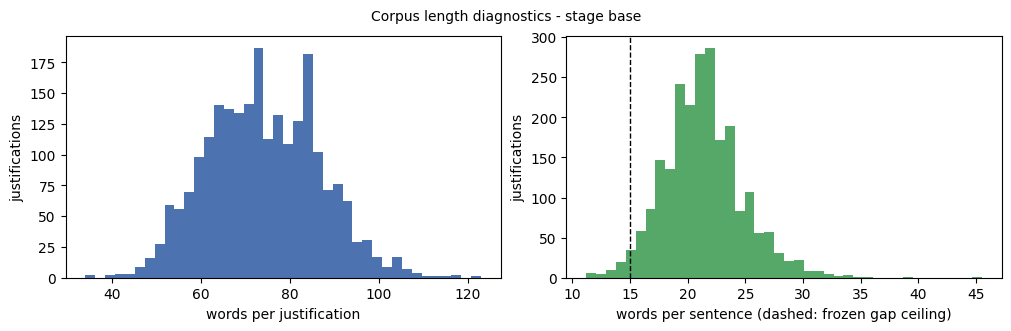

In [12]:
# ============================================================
# 6. Current-corpus length diagnostics
# ============================================================
#
# Descriptive only. These statistics motivated the 15-token component-gap
# ceiling during base-pipeline development, but they no longer feed back into
# it: the threshold is frozen and applied identically to every stage. Reported
# here so the current corpus can be compared against the corpus the threshold
# was set on.

length_by_run = (
    justification_metrics_df
    .groupby(["model", "decoding_group", "run_label"], observed=True)
    .agg(n_justifications=("justification_id", "size"),
         mean_words=("n_words", "mean"),
         mean_sentences=("n_sentences", "mean"),
         mean_words_per_sentence=("words_per_sentence", "mean"))
    .reset_index()
)
length_by_model = (
    justification_metrics_df
    .groupby("model", observed=True)
    .agg(n_justifications=("justification_id", "size"),
         mean_words=("n_words", "mean"),
         median_words=("n_words", "median"),
         mean_sentences=("n_sentences", "mean"),
         median_sentences=("n_sentences", "median"),
         mean_words_per_sentence=("words_per_sentence", "mean"))
    .reset_index()
)

print("Per-model justification length")
display(length_by_model.round(2))

# The sentence-length figure the frozen gap ceiling was set against.
sentence_lengths = justification_metrics_df["words_per_sentence"].dropna()
print(f"words per sentence, whole corpus: "
      f"mean {sentence_lengths.mean():.1f}, "
      f"median {sentence_lengths.median():.1f}")
print(f"frozen MAX_COMPONENT_GAP_TOKENS = {MAX_COMPONENT_GAP_TOKENS} "
      f"(set on the BASE corpus during development, not re-derived here)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), layout="constrained")
axes[0].hist(justification_metrics_df["n_words"], bins=40, color="#4c72b0")
axes[0].set(xlabel="words per justification", ylabel="justifications")
axes[1].hist(sentence_lengths, bins=40, color="#55a868")
axes[1].axvline(MAX_COMPONENT_GAP_TOKENS, color="black", linestyle="--",
                linewidth=1)
axes[1].set(xlabel="words per sentence (dashed: frozen gap ceiling)",
            ylabel="justifications")
fig.suptitle(f"Corpus length diagnostics - stage {CONFIG.stage}", fontsize=10)
plt.show()
